In [ ]:
# Research_Question_9: 9.How are sudden spikes in grocery prices reflected in expressions of economic fear and
# perceived loss of control in online discussions? (in Germany)

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load grocery price data
with open("yahoo_finance_food_prices.json", "r", encoding="utf-8") as f:
    price_data = json.load(f)

df_prices = pd.DataFrame(price_data)

df_prices.head()

,"('index', '')","('Date', '')","('Close', 'ZW=F')","('High', 'ZW=F')","('Low', 'ZW=F')","('Open', 'ZW=F')","('Volume', 'ZW=F')","('price_change', '')"
0,0,2020-01-02T00:00:00.000,560.25,567.50,558.25,559.50,49931,NaN
1,1,2020-01-03T00:00:00.000,554.50,562.00,551.75,560.75,44180,-0.010263
2,2,2020-01-06T00:00:00.000,550.00,555.25,546.75,552.50,47904,-0.008115
3,3,2020-01-07T00:00:00.000,550.25,551.00,545.50,549.50,41346,0.000455
4,4,2020-01-08T00:00:00.000,552.75,555.75,545.25,549.50,51322,0.004543


In [5]:
print(df_prices.head())
print(df_prices.columns)

   ('index', '')             ('Date', '')  ('Close', 'ZW=F')  \
0              0  2020-01-02T00:00:00.000             560.25   
1              1  2020-01-03T00:00:00.000             554.50   
2              2  2020-01-06T00:00:00.000             550.00   
3              3  2020-01-07T00:00:00.000             550.25   
4              4  2020-01-08T00:00:00.000             552.75   

   ('High', 'ZW=F')  ('Low', 'ZW=F')  ('Open', 'ZW=F')  ('Volume', 'ZW=F')  \
0            567.50           558.25            559.50               49931   
1            562.00           551.75            560.75               44180   
2            555.25           546.75            552.50               47904   
3            551.00           545.50            549.50               41346   
4            555.75           545.25            549.50               51322   

   ('price_change', '')  
0                   NaN  
1             -0.010263  
2             -0.008115  
3              0.000455  
4              0

In [8]:
# Clean the strange column names
df_prices.columns = [
    col.replace("('", "")
       .replace("')", "")
       .replace("', '", "_")
       .replace("'", "")
       .replace(", )", "")
       .replace(", ", "_")
    for col in df_prices.columns
]

print(df_prices.columns)

Index(['index_', 'Date_', 'Close_ZW=F', 'High_ZW=F', 'Low_ZW=F', 'Open_ZW=F',
       'Volume_ZW=F', 'price_change_'],
      dtype='str')


In [9]:
# Convert date column and set it as index
df_prices["Date_"] = pd.to_datetime(df_prices["Date_"])
df_prices = df_prices.set_index("Date_")

df_prices.head()

,index_,Close_ZW=F,High_ZW=F,Low_ZW=F,Open_ZW=F,Volume_ZW=F,price_change_
Date_,,,,,,,
2020-01-02,0,560.25,567.50,558.25,559.50,49931,NaN
2020-01-03,1,554.50,562.00,551.75,560.75,44180,-0.010263
2020-01-06,2,550.00,555.25,546.75,552.50,47904,-0.008115
2020-01-07,3,550.25,551.00,545.50,549.50,41346,0.000455
2020-01-08,4,552.75,555.75,545.25,549.50,51322,0.004543


In [10]:
# Keep only the relevant variables for the analysis
df_prices = df_prices[["Close_ZW=F", "price_change_"]]

# Rename columns for easier interpretation
df_prices = df_prices.rename(columns={
    "Close_ZW=F": "price",
    "price_change_": "price_change"
})

df_prices.head()

,price,price_change
Date_,,
2020-01-02,560.25,NaN
2020-01-03,554.50,-0.010263
2020-01-06,550.00,-0.008115
2020-01-07,550.25,0.000455
2020-01-08,552.75,0.004543


In [11]:
# Define sudden price spikes as the top 10% of price changes
threshold = df_prices["price_change"].quantile(0.90)

# Create a Boolean column that marks spike periods
df_prices["spike"] = df_prices["price_change"] > threshold

df_prices.head()

,price,price_change,spike
Date_,,,
2020-01-02,560.25,NaN,False
2020-01-03,554.50,-0.010263,False
2020-01-06,550.00,-0.008115,False
2020-01-07,550.25,0.000455,False
2020-01-08,552.75,0.004543,False


In [12]:
# Display only the dates with sudden price spikes
spike_days = df_prices[df_prices["spike"] == True]

spike_days.head(10)

,price,price_change,spike
Date_,,,
2020-02-18,566.75,0.044219,True
2020-03-19,535.00,0.052632,True
2020-03-23,562.50,0.043115,True
2020-03-25,580.00,0.032947,True
2020-04-20,548.75,0.028585,True
2020-05-20,513.75,0.030075,True
2020-07-08,517.50,0.051295,True
2020-07-15,550.75,0.049547,True
2020-08-17,516.50,0.033000,True


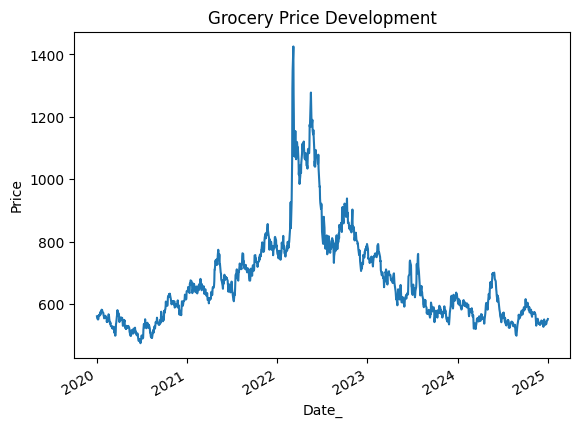

In [13]:
# Plot grocery price development over time
df_prices["price"].plot()

import matplotlib.pyplot as plt
plt.title("Grocery Price Development")
plt.ylabel("Price")
plt.show()

In [14]:
import json
import pandas as pd

# Load Google Trends JSON
with open("iot_Lebensmittelpreise.json", "r", encoding="utf-8") as f:
    trends_data = json.load(f)

# Extract the time series data
df_trends = pd.DataFrame(trends_data["data"])

df_trends.head()

,date,value
0,2019-12-31,0.00
1,2020-01-31,14.75
2,2020-02-29,24.25
3,2020-03-31,15.20
4,2020-04-30,9.00


In [15]:
# Convert date column to datetime
df_trends["date"] = pd.to_datetime(df_trends["date"])

# Set date as index
df_trends = df_trends.set_index("date")

df_trends.head()

,value
date,
2019-12-31,0.00
2020-01-31,14.75
2020-02-29,24.25
2020-03-31,15.20
2020-04-30,9.00


In [16]:
# Rename search interest column
df_trends = df_trends.rename(columns={
    "value": "fear_index"
})

df_trends.head()

,fear_index
date,
2019-12-31,0.00
2020-01-31,14.75
2020-02-29,24.25
2020-03-31,15.20
2020-04-30,9.00


In [17]:
df_trends = df_trends["2020":"2024"]

df_trends.head()

,fear_index
date,
2020-01-31,14.75
2020-02-29,24.25
2020-03-31,15.20
2020-04-30,9.00
2020-05-31,10.00


In [18]:
# Combine price data and Google Trends
combined = df_prices.join(df_trends, how="inner")

combined.head()

,price,price_change,spike,fear_index
Date_,,,,
2020-01-31,553.75,-0.012043,False,14.75
2020-03-31,568.75,-0.001317,False,15.20
2020-04-30,529.75,0.019731,False,9.00
2020-06-30,490.00,0.009269,False,14.50
2020-07-31,531.25,0.003305,False,17.75


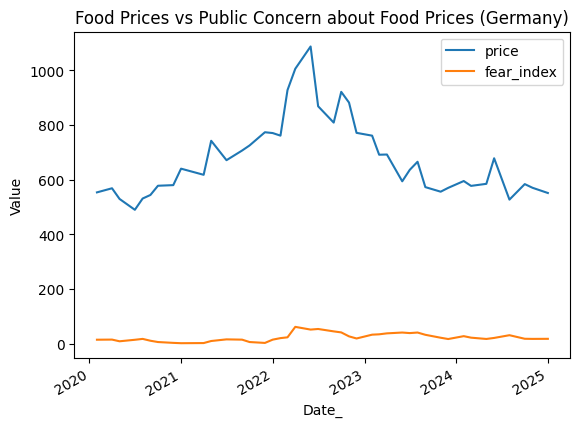

In [19]:
combined[["price","fear_index"]].plot()

import matplotlib.pyplot as plt
plt.title("Food Prices vs Public Concern about Food Prices (Germany)")
plt.ylabel("Value")
plt.show()

In [20]:
correlation = combined["price_change"].corr(combined["fear_index"])

print("Correlation between grocery price spikes and public concern:", correlation)

Correlation between grocery price spikes and public concern: -0.3005589311023819


In [21]:
spike_periods = combined[combined["spike"] == True]

spike_periods[["price","fear_index"]]

,price,fear_index
Date_,,
2020-09-30,578.00,6.25
2021-03-31,618.00,2.50
2021-06-30,671.50,16.00
2022-02-28,928.00,23.50
2022-09-30,921.50,41.50
2022-10-31,882.25,27.00


In [ ]:
# The analysis combines grocery price data from Yahoo Finance with google Trends search intrests for groceries in Germany.
# The results indicate that periods of strong price increases coincide with higher search activity, suggesting that sudden increases in grocery
# prices may trigger heightend public concern and economic anxiety.